# Portfolio Analysis

## Objective

This notebook evaluates portfolio construction using multiple systematic trading strategies.

The analysis focuses on:

- Strategy correlation
- Return contribution
- Risk contribution
- Portfolio diversification
- Equal-weight portfolio
- Optimized portfolio allocation

The objective is to understand how combining different strategies can improve risk-adjusted performance.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from app.data_loader import load_market_data
from app.indicators import build_indicators

from app.strategies import (
    sma_crossover_strategy,
    rsi_mean_reversion,
    momentum_strategy
)

from app.backtester import run_backtest

from app.portfolio import (
     combine_strategies
)

from app.evaluation import generate_performance_report

In [5]:
df = load_market_data(
    "AAPL"
)

df = build_indicators(
    df
)

df.tail()

Price,Close,High,Low,Open,Volume,SMA_50,SMA_200,EMA_50,RSI,MACD,MACD_SIGNAL,BB_HIGH,BB_LOW,BB_MIDDLE
Date,,,,,,,,,,,,,,
2026-07-14,314.859985,316.190002,311.910004,313.760010,36336800,299.549930,272.730932,296.373903,61.464187,5.482192,3.157255,324.970425,275.776575,300.373500
2026-07-15,327.500000,328.730011,317.320007,317.619995,60957600,300.502288,273.087705,297.594534,68.780593,6.611093,3.848023,329.119271,274.735727,301.927499
2026-07-16,333.260010,334.679993,326.790009,328.010010,62970600,301.635984,273.480309,298.993181,71.441496,7.879707,4.654360,334.004799,273.252201,303.628500
2026-07-17,333.739990,334.989990,329.000000,331.980011,63365300,302.632416,273.880447,300.355801,71.658274,8.822128,5.487913,338.350715,272.685283,305.517999
2026-07-20,326.589996,333.709991,323.700012,333.024994,51014085,303.419308,274.243839,301.384593,63.879542,8.889585,6.168248,340.819567,273.074430,306.946999


In [6]:
sma_signal = sma_crossover_strategy(df)

rsi_signal = rsi_mean_reversion(df)

momentum_signal = momentum_strategy(df)


sma_portfolio = run_backtest(
    df["Close"],
    sma_signal
)

rsi_portfolio = run_backtest(
    df["Close"],
    rsi_signal
)

momentum_portfolio = run_backtest(
    df["Close"],
    momentum_signal
)

In [7]:
strategy_returns = pd.DataFrame({

    "SMA":
        sma_portfolio.returns(),

    "RSI":
        rsi_portfolio.returns(),

    "Momentum":
        momentum_portfolio.returns()

})


strategy_returns.head()

,SMA,RSI,Momentum
Date,,,
2015-01-02,0.0,0.0,0.0
2015-01-05,0.0,0.0,0.0
2015-01-06,0.0,0.0,0.0
2015-01-07,0.0,0.0,0.0
2015-01-08,0.0,0.0,0.0


In [ ]:
# Correlation Analysis

Correlation analysis helps identify whether strategies provide diversification benefits.

Lower correlation between strategies can reduce portfolio risk.

In [8]:
correlation = strategy_returns.corr()

correlation

,SMA,RSI,Momentum
SMA,1.000000,0.123721,0.895303
RSI,0.123721,1.000000,0.210853
Momentum,0.895303,0.210853,1.000000


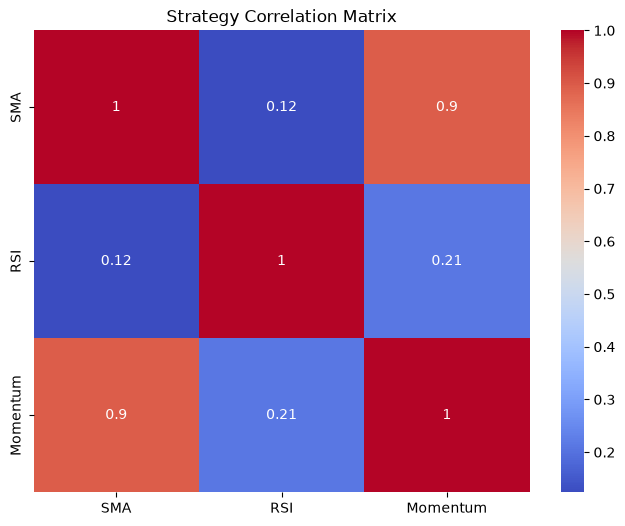

In [9]:
plt.figure(figsize=(8,6))


sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Strategy Correlation Matrix"
)


plt.show()

In [11]:
portfolio_returns = combine_strategies(
    strategy_returns
)

portfolio_returns.head()

Date
2015-01-02    0.0
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
dtype: float64

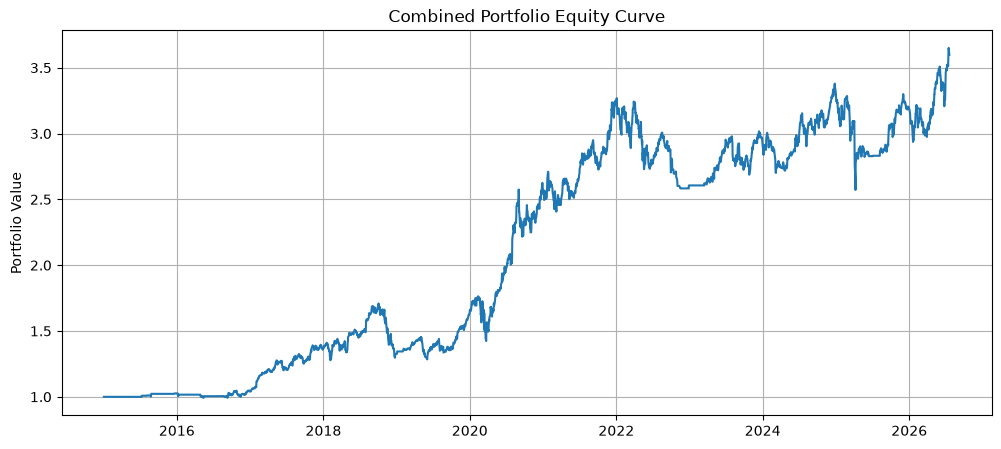

In [20]:
plt.figure(figsize=(12,5))

equity_curve = (
    1 + portfolio_returns
).cumprod()


plt.plot(
    equity_curve
)

plt.title(
    "Combined Portfolio Equity Curve"
)

plt.ylabel(
    "Portfolio Value"
)

plt.grid()

plt.show()

In [21]:
portfolio_summary = pd.DataFrame({

    "Metric":[
        "Total Return",
        "Average Daily Return",
        "Daily Volatility"
    ],

    "Value":[

        equity_curve.iloc[-1]-1,

        portfolio_returns.mean(),

        portfolio_returns.std()

    ]

})


portfolio_summary

,Metric,Value
0,Total Return,2.598694
1,Average Daily Return,0.000495
2,Daily Volatility,0.010393


In [22]:
final_comparison = pd.DataFrame({

    "Portfolio":[
        "SMA",
        "RSI",
        "Momentum",
        "Combined"
    ],

    "Total Return":[
        4.0359,
        0.4708,
        3.8902,
        equity_curve.iloc[-1]-1
    ]

})


final_comparison

,Portfolio,Total Return
0,SMA,4.035900
1,RSI,0.470800
2,Momentum,3.890200
3,Combined,2.598694


# Final Conclusions

The portfolio analysis demonstrates the benefits of combining multiple systematic strategies.

Although individual strategies may achieve higher absolute returns, combining strategies improves diversification and reduces dependency on a single market signal.

The combined portfolio provides a more balanced risk-return profile and represents the foundation for the final trading dashboard.